In [1]:
# import libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, col, concat, desc, explode, lit, min, max, split, udf,regexp_extract,when
from pyspark.sql.types import IntegerType,DateType
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.feature import StandardScaler,OneHotEncoder,CountVectorizer, IDF, Normalizer, RegexTokenizer, StandardScaler, StopWordsRemover, StringIndexer, VectorAssembler
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.sql import functions as F
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import re
import pandas as pd
from pyspark.sql import Window as window
import warnings

In [2]:
#ignore warning
warnings.filterwarnings('ignore')
#building spark
spark = SparkSession.builder \
    .appName("musicPredict") \
.getOrCreate()

# 1.Data Loading

In [3]:
#path for the data
#hdfspath = 'mini_sparkify_event_data.json' 
hdfspath = 'hdfs://www.dlmd.com:9000/input/mini_sparkify_event_data.json'
#load json datasets
jsondataframe = spark.read.json(hdfspath)
#dataframe conversion
music_data_preview = jsondataframe.toPandas()

# 2.Data Preview

In [4]:
jsondataframe.printSchema()

root
 |-- artist: string (nullable = true)
 |-- auth: string (nullable = true)
 |-- firstName: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- itemInSession: long (nullable = true)
 |-- lastName: string (nullable = true)
 |-- length: double (nullable = true)
 |-- level: string (nullable = true)
 |-- location: string (nullable = true)
 |-- method: string (nullable = true)
 |-- page: string (nullable = true)
 |-- registration: long (nullable = true)
 |-- sessionId: long (nullable = true)
 |-- song: string (nullable = true)
 |-- status: long (nullable = true)
 |-- ts: long (nullable = true)
 |-- userAgent: string (nullable = true)
 |-- userId: string (nullable = true)



In [5]:
#preview data row and column number
music_data_preview.shape

(286500, 18)

In [6]:
#preview top 5 row of data
music_data_preview[:5]

,artist,auth,firstName,gender,itemInSession,lastName,length,level,location,method,page,registration,sessionId,song,status,ts,userAgent,userId
0,Martha Tilston,Logged In,Colin,M,50,Freeman,277.89016,paid,"Bakersfield, CA",PUT,NextSong,1.538173e+12,29,Rockpools,200,1538352117000,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,30
1,Five Iron Frenzy,Logged In,Micah,M,79,Long,236.09424,free,"Boston-Cambridge-Newton, MA-NH",PUT,NextSong,1.538332e+12,8,Canada,200,1538352180000,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",9
2,Adam Lambert,Logged In,Colin,M,51,Freeman,282.82730,paid,"Bakersfield, CA",PUT,NextSong,1.538173e+12,29,Time For Miracles,200,1538352394000,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,30
3,Enigma,Logged In,Micah,M,80,Long,262.71302,free,"Boston-Cambridge-Newton, MA-NH",PUT,NextSong,1.538332e+12,8,Knocking On Forbidden Doors,200,1538352416000,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",9
4,Daft Punk,Logged In,Colin,M,52,Freeman,223.60771,paid,"Bakersfield, CA",PUT,NextSong,1.538173e+12,29,Harder Better Faster Stronger,200,1538352676000,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,30


In [7]:
#display data count which is not null
music_data_preview.count()

artist           228108
auth             286500
firstName        278154
gender           278154
itemInSession    286500
lastName         278154
length           228108
level            286500
location         278154
method           286500
page             286500
registration     278154
sessionId        286500
song             228108
status           286500
ts               286500
userAgent        278154
userId           286500
dtype: int64

# 3.Data Cleaning & Pre-processing

In [8]:
#remove null userId
jsondataframe=jsondataframe.filter(jsondataframe["userId"] != "")
print("The number of records filtered by userid is as follows: ",jsondataframe.count())

The number of records filtered by userid is as follows:  278154


In [9]:
#remove the duplicate userId
distinctUserid=jsondataframe.select("userId").dropDuplicates().count()
print("Number of different user ids:",distinctUserid)

Number of different user ids: 225


In [10]:
#convert the timestamp to year:month:day hour:minute:seconds format, rename as BehaviorTime
convertTime = udf(lambda x:datetime.datetime.fromtimestamp(x/1000.0).strftime ( "%Y-%m-%d %H:%M:%S"))
jsondataframe=jsondataframe.withColumn("BehaviorTime",convertTime('ts'))

In [11]:
#retrieve hour data as hour based on the timestamp feature
get_hour = udf(lambda x: datetime.datetime.fromtimestamp(x / 1000.0).hour)
jsondataframe = jsondataframe.withColumn("hour",get_hour(jsondataframe.ts).cast('int'))

In [12]:
#retrieve week data as weekday based on the timestamp feature
get_week = udf(lambda x: datetime.datetime.fromtimestamp(x / 1000.0).weekday())
jsondataframe = jsondataframe.withColumn("weekday",get_week(jsondataframe.ts).cast('int'))

In [13]:
#retrieve user state data based on the location feature
jsondataframe = jsondataframe.withColumn("location_state",regexp_extract("location",",(.*)",1))

In [14]:
#retreive user device based on the userAgent feature
device_function = F.udf(lambda x: x.split('(')[1].split(";")[0].split(" ")[0] .replace('"', ' ').strip() if not x is None else "")
jsondataframe = jsondataframe.withColumn("device",device_function(jsondataframe.userAgent))


In [15]:
#retrieve user browser based on the userAgent feature
browser_function = F.udf(lambda x: x.rsplit(' ', 1)[1].rsplit('/', 1)[0] .replace('"', ' ', 1).strip() if not x is None else "")
jsondataframe = jsondataframe.withColumn("browser",browser_function(jsondataframe.userAgent))

In [16]:
#summarize the interaction and event logs from the page feature
music_data_preview['page'].value_counts()

NextSong                     228108
Home                          14457
Thumbs Up                     12551
Add to Playlist                6526
Add Friend                     4277
Roll Advert                    3933
Login                          3241
Logout                         3226
Thumbs Down                    2546
Downgrade                      2055
Help                           1726
Settings                       1514
About                           924
Upgrade                         499
Save Settings                   310
Error                           258
Submit Upgrade                  159
Submit Downgrade                 63
Cancel                           52
Cancellation Confirmation        52
Register                         18
Submit Registration               5
Name: page, dtype: int64

In [17]:
#define y function for cancellation confirmation
y_function = udf(lambda x:1 if x=='Cancellation Confirmation' else 0,IntegerType())
jsondataframe = jsondataframe.withColumn('Y', y_function('page'))

#sort the event logs by user id,label the user according churn label
window_userid =window.partitionBy('userId')
jsondataframe = jsondataframe.withColumn('label',max('Y').over(window_userid))

jsondataframe.toPandas()[:5]

,artist,auth,firstName,gender,itemInSession,lastName,length,level,location,method,...,userAgent,userId,BehaviorTime,hour,weekday,location_state,device,browser,Y,lable
0,Sleeping With Sirens,Logged In,Darianna,F,0,Carpenter,202.97098,free,"Bridgeport-Stamford-Norwalk, CT",PUT,...,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",100010,2018-10-08 20:58:54,20,0,CT,iPhone,Safari,0,0
1,Francesca Battistelli,Logged In,Darianna,F,1,Carpenter,196.54485,free,"Bridgeport-Stamford-Norwalk, CT",PUT,...,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",100010,2018-10-08 21:02:16,21,0,CT,iPhone,Safari,0,0
2,Brutha,Logged In,Darianna,F,2,Carpenter,263.13098,free,"Bridgeport-Stamford-Norwalk, CT",PUT,...,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",100010,2018-10-08 21:05:32,21,0,CT,iPhone,Safari,0,0
3,None,Logged In,Darianna,F,3,Carpenter,NaN,free,"Bridgeport-Stamford-Norwalk, CT",PUT,...,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",100010,2018-10-08 21:05:33,21,0,CT,iPhone,Safari,0,0
4,Josh Ritter,Logged In,Darianna,F,4,Carpenter,316.23791,free,"Bridgeport-Stamford-Norwalk, CT",PUT,...,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",100010,2018-10-08 21:09:55,21,0,CT,iPhone,Safari,0,0


In [18]:
#user lost count
lossCustCnt=jsondataframe.filter(jsondataframe.Y==1).count()
nonelossCustCnt=jsondataframe.filter(jsondataframe.Y==0).count()
print("Number of lost records：",lossCustCnt)
print("No lost records：",nonelossCustCnt)

jsondataframe.toPandas().to_csv("kk.csv")

Number of lost records： 52
No lost records： 278102


# 4.Data Analysis

# 1.Analysis on User Churn

+-----+-----+
|lable|count|
+-----+-----+
|    1|   52|
|    0|  173|
+-----+-----+



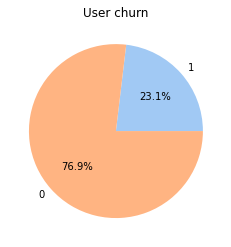

In [19]:
#summarize number of user churn
df1=jsondataframe.groupBy("label").agg(F.countDistinct("userId").alias('count'))
df1.show()
df1=df1.toPandas()
sns.set_palette("pastel")
plt.figure(figsize=(4,4))
plt.pie(df1['count'], labels=df1['lable'], autopct='%1.1f%%')
plt.title('User churn')
plt.show()

#  2.Analysis on User Churn based on User Gender

+------+-----+-----+
|gender|lable|count|
+------+-----+-----+
|     M|    1|   32|
|     F|    1|   20|
+------+-----+-----+



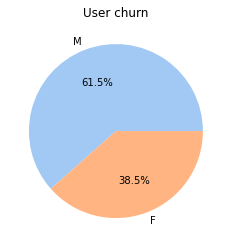

In [20]:
#summarize user churn based on gender
df2=jsondataframe.dropDuplicates(["userId", "gender","lable"]).filter(F.col('lable')==1).groupBy(["gender","lable"]).agg(F.count("lable").alias('count'))

df2.show()

df2=df2.toPandas()
sns.set_palette("pastel")
plt.figure(figsize=(4,4))
plt.pie(df2['count'], labels=df2['gender'], autopct='%1.1f%%')
plt.title('User churn')
plt.show()

# 3.Analysis of User Churn based on User Device

+---------+-----+-----+
|   device|lable|count|
+---------+-----+-----+
|      X11|    1|    5|
|   iPhone|    1|    4|
|Macintosh|    1|   19|
|  Windows|    1|   24|
+---------+-----+-----+



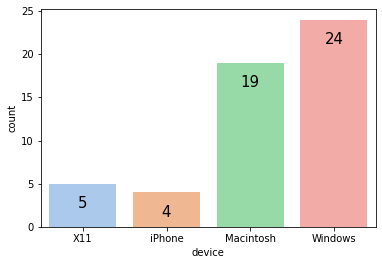

In [21]:
#summarize user churn based on device used
df3=jsondataframe.dropDuplicates(["userId", "device","lable"]).filter(F.col('lable')==1).groupBy(["device","lable"]).agg(F.count("lable").alias('count'))
df3.show()


df3=df3.toPandas()
sns.set_palette("pastel")
chart=sns.barplot(data=df3, x='device', y='count')

for p in chart.patches:
             chart.annotate("%.0f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0, -20),
                 textcoords='offset points')

plt.show()

# 4.Analysis on User Churn based on User Browser

+-------+-----+-----+
|browser|lable|count|
+-------+-----+-----+
| Safari|    1|   35|
|Firefox|    1|   16|
|  Gecko|    1|    1|
+-------+-----+-----+



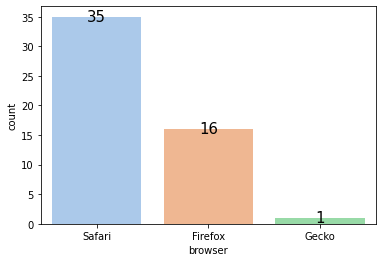

In [22]:
#summarize user churn based on browser used.
df4=jsondataframe.dropDuplicates(["userId", "browser","lable"]).filter(F.col('lable')==1).groupBy(["browser","lable"]).agg(F.count("lable").alias('count'))
df4.show()


df4=df4.toPandas()
sns.set_palette("pastel")
chart=sns.barplot(data=df4, x='browser', y='count')

for p in chart.patches:
             chart.annotate("%.0f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0, 0),
                 textcoords='offset points')

plt.show()

# 5.Analysis on User Churn based on User Loaction

+--------------+-----+-----+
|location_state|lable|count|
+--------------+-----+-----+
|            MS|    1|    2|
|            IN|    1|    1|
|            AR|    1|    1|
|            WA|    1|    2|
|            KY|    1|    2|
|            LA|    1|    1|
|            AL|    1|    2|
|            FL|    1|    3|
|            CA|    1|    6|
|            CO|    1|    2|
|            AZ|    1|    2|
|            MI|    1|    3|
|      TN-MS-AR|    1|    1|
|            MD|    1|    1|
|            OR|    1|    1|
|            OH|    1|    2|
|            NC|    1|    1|
|         VA-NC|    1|    1|
|      IL-IN-WI|    1|    1|
|            NY|    1|    1|
|         IL-MO|    1|    1|
|   PA-NJ-DE-MD|    1|    2|
|      NY-NJ-PA|    1|    5|
|   DC-VA-MD-WV|    1|    1|
|         MO-IL|    1|    1|
|         MO-KS|    1|    1|
|            TX|    1|    3|
|            SC|    1|    1|
|            MT|    1|    1|
+--------------+-----+-----+



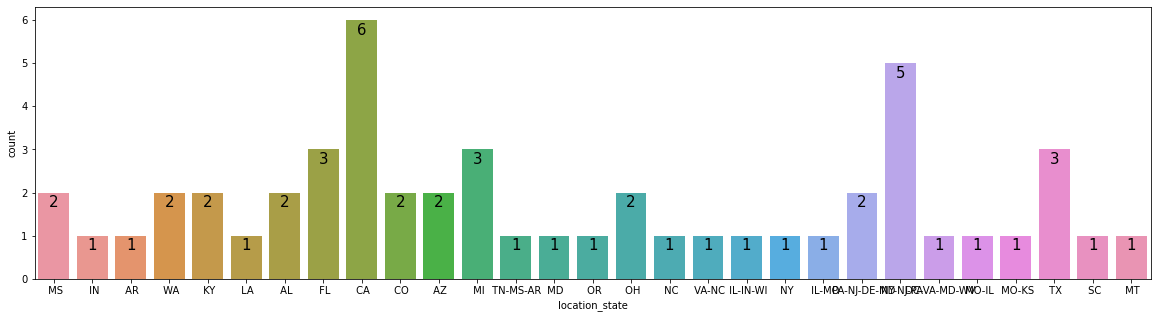

In [23]:
#summarize user churn based o their location
df5=jsondataframe.dropDuplicates(["userId", "location_state","lable"]).filter(F.col('lable')==1).groupBy(["location_state","lable"]).agg(F.count("lable").alias('count'))
df5.show(50)


df5=df5.toPandas()
sns.set_palette("pastel")


fig,ax = plt.subplots(1,1,figsize=(20,5))
chart=sns.barplot(data=df5, x='location_state', y='count')

for p in chart.patches:
             chart.annotate("%.0f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0,-10),
                 textcoords='offset points')

plt.show()

#  6.Analysis of User Churn based on User Level

+-----+-----+-----+
|level|lable|count|
+-----+-----+-----+
| paid|    1|   36|
| free|    1|   46|
+-----+-----+-----+



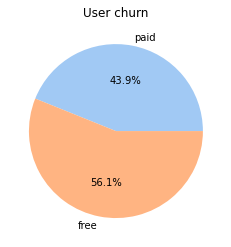

In [24]:
#summarize user churn on their user level
df6=jsondataframe.dropDuplicates(["userId", "level","lable"]).filter(F.col('lable')==1).groupBy(["level","lable"]).agg(F.count("lable").alias('count'))
df6.show()

df6=df6.toPandas()
sns.set_palette("pastel")
plt.figure(figsize=(4,4))
plt.pie(df6['count'], labels=df6['level'], autopct='%1.1f%%')
plt.title('User churn')
plt.show()

# 7.Analysis on User Event Page

+---------------+------+
|page           |count |
+---------------+------+
|NextSong       |228108|
|Thumbs Up      |12551 |
|Home           |10082 |
|Add to Playlist|6526  |
|Add Friend     |4277  |
|Roll Advert    |3933  |
|Logout         |3226  |
|Thumbs Down    |2546  |
|Downgrade      |2055  |
|Settings       |1514  |
+---------------+------+



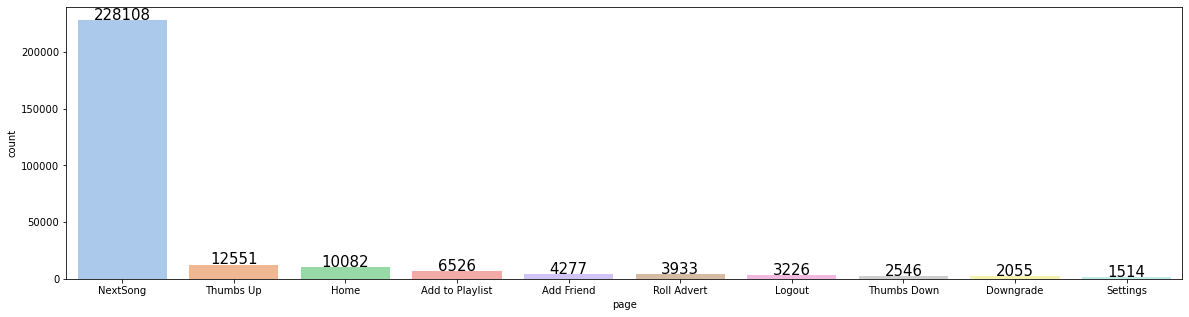

In [25]:
#summarize user event count on pages
df7=jsondataframe.groupBy('page').count().sort("count", ascending=False).limit(10)
df7.show(truncate=False)


df7=df7.toPandas()
sns.set_palette("pastel")

fig,ax = plt.subplots(1,1,figsize=(20,5))
chart=sns.barplot(data=df7, x='page', y='count')

for p in chart.patches:
             chart.annotate("%.0f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0,5),
                 textcoords='offset points')

plt.show()

# 8.Analysis on the Number of Streaming for Artist

+----------------------+-----+
|artist                |count|
+----------------------+-----+
|Kings Of Leon         |1841 |
|Coldplay              |1813 |
|Florence + The Machine|1236 |
|Dwight Yoakam         |1135 |
|BjÃÂ¶rk              |1133 |
|The Black Keys        |1125 |
|Muse                  |1090 |
|Justin Bieber         |1044 |
|Jack Johnson          |1007 |
|Eminem                |953  |
+----------------------+-----+



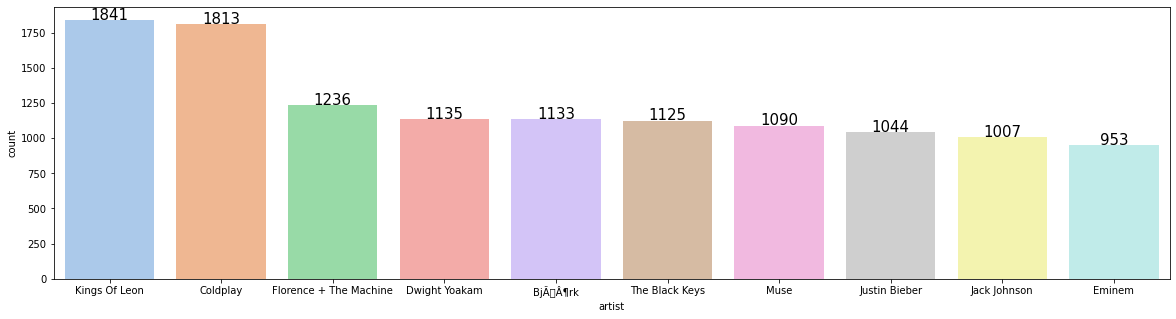

In [26]:
#summarize of the number of artist 
df8=jsondataframe.filter(jsondataframe.artist != 'null').groupBy('artist').count().sort("count", ascending=False).limit(10)
df8.show(truncate=False)


df8=df8.toPandas()[:10]
sns.set_palette("pastel")

fig,ax = plt.subplots(1,1,figsize=(20,5))
chart=sns.barplot(data=df8, x='artist', y='count')

for p in chart.patches:
             chart.annotate("%.0f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0,5),
                 textcoords='offset points')       

plt.show()

# 5.Feature Engineering

In [27]:
jsondataframe=jsondataframe \
.withColumn('gender', F.when(F.col('gender') == "M", 1).otherwise(0)) \
.withColumn('level', F.when(F.col('level') == "free", 1).otherwise(0)) \
.groupby(['userId','gender']).agg(
    F.max('label').alias('label'), 
    F.last('location_state').alias('state'), 
    F.last('device').alias('device'), 
    F.last('browser').alias('browser'),  
    F.last('level').alias('level'),
    F.datediff(F.from_unixtime((F.max("ts"))/1000).cast(DateType()),
               F.from_unixtime(F.max('registration')/1000).cast(DateType())).alias('lifetime'), 
    F.countDistinct('sessionId').alias('session_count'),  
    F.count('song').alias('song_count'),   
    F.countDistinct('song').alias('unique_song_count'), 
    F.count('page').alias('events'),
    F.count(when(col('page')=='Thumbs Up',col('page'))).alias('like_song_count'), 
    F.round(F.count(when(col('page')=='Thumbs Up',col('page')))/F.countDistinct('song'), 2).alias('like_song_count_ratio'), 
    F.count(when(col('page')=='Thumbs Down',col('page'))).alias('dislike_song_count'),
    F.round(F.count(when(col('page')=='Thumbs Down',col('page')))/F.countDistinct('song'), 2).alias('dislike_song_count_ratio'), 
    F.count(when(col('page')=='Add to Playlist',col('page'))).alias('collect_song_count'), 
    F.round(F.count(when(col('page')=='Add to Playlist',col('page')))/F.countDistinct('song'), 2).alias('collect_song_count_ratio')     
)

jsondataframe.toPandas()[:5]


,userId,gender,lable,state,device,browser,level,lifetime,session_count,song_count,unique_song_count,events,like_song_count,like_song_count_ratio,dislike_song_count,dislike_song_count_ratio,collect_song_count,collect_song_count_ratio
0,19,0,0,OH,Windows,Gecko,0,21,1,216,209,259,5,0.02,2,0.01,8,0.04
1,37,1,0,TX,Windows,Safari,0,95,15,1412,1275,1682,75,0.06,11,0.01,37,0.03
2,73,0,1,NY,Windows,Firefox,0,50,6,377,363,457,14,0.04,7,0.02,11,0.03
3,100005,1,1,LA,Macintosh,Safari,1,86,5,154,153,216,7,0.05,3,0.02,3,0.02
4,134,1,0,IN,Macintosh,Safari,1,66,4,37,37,52,3,0.08,1,0.03,2,0.05


In [28]:
#Vectorization of features

#dfeine string indexer
StringIndexer_state = StringIndexer(inputCol='state', outputCol='state_index')
StringIndexer_device = StringIndexer(inputCol='device', outputCol='device_index') 
StringIndexer_browser = StringIndexer(inputCol='browser', outputCol='browser_index') 

#define one hot encoder
OneHotEncoder_state= OneHotEncoder(inputCol='state_index', outputCol='state_vector')
OneHotEncoder_device= OneHotEncoder(inputCol='device_index', outputCol='device_vector')
OneHotEncoder_browser= OneHotEncoder(inputCol='browser_index', outputCol='browser_vector')

#define pipeline and transform model
my_pipeline = Pipeline(stages=[StringIndexer_state, StringIndexer_device, StringIndexer_browser, OneHotEncoder_state,OneHotEncoder_device,OneHotEncoder_browser])
pipelineModel=my_pipeline.fit(jsondataframe)
jsondataframe =pipelineModel.transform(jsondataframe)

jsondataframe.toPandas()[:5]

,userId,gender,lable,state,device,browser,level,lifetime,session_count,song_count,...,dislike_song_count,dislike_song_count_ratio,collect_song_count,collect_song_count_ratio,state_index,device_index,browser_index,state_vector,device_vector,browser_vector
0,19,0,0,OH,Windows,Gecko,0,21,1,216,...,2,0.01,8,0.04,21.0,0.0,2.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 0.0, 0.0, 0.0)","(0.0, 0.0, 1.0)"
1,37,1,0,TX,Windows,Safari,0,95,15,1412,...,11,0.01,37,0.03,1.0,0.0,0.0,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 0.0, 0.0, 0.0)","(1.0, 0.0, 0.0)"
2,73,0,1,NY,Windows,Firefox,0,50,6,377,...,7,0.02,11,0.03,10.0,0.0,1.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 0.0, 0.0, 0.0)","(0.0, 1.0, 0.0)"
3,100005,1,1,LA,Macintosh,Safari,1,86,5,154,...,3,0.02,3,0.02,30.0,1.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 1.0, 0.0, 0.0, 0.0)","(1.0, 0.0, 0.0)"
4,134,1,0,IN,Macintosh,Safari,1,66,4,37,...,1,0.03,2,0.05,24.0,1.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 1.0, 0.0, 0.0, 0.0)","(1.0, 0.0, 0.0)"


In [29]:
#Analyze all vectorized features
dfcorr=jsondataframe.select(
    "gender",
    "label",
    "state_index",
    "device_index",
    "browser_index",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio"
)
#retrieve the correlation of features
dfcorr=dfcorr.toPandas().corr()

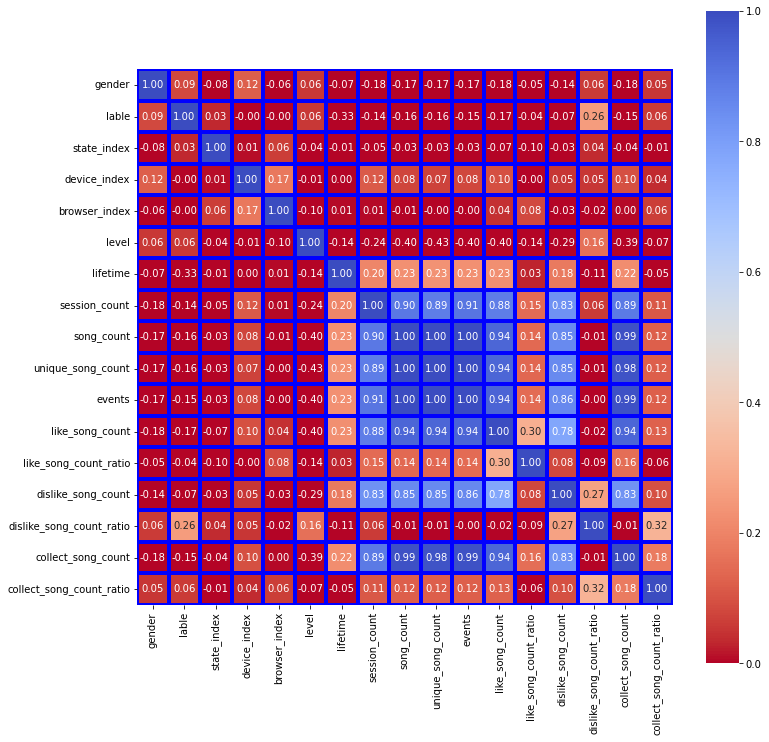

In [30]:
#produce heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(dfcorr,
            annot=True,  
            center=0.5, 
            fmt='.2f',  
            linewidth=3,  
            linecolor='blue', 
            vmin=0, vmax=1,  
            xticklabels=True, yticklabels=True,  
            square=True,  
            cbar=True,  
            cmap='coolwarm_r', 
            )    

In [31]:
#sort the correlation of features with label by descending order
dfcorr_soft=dfcorr['label'].sort_values(ascending=False)
print(dfcorr_soft)

lable                       1.000000
dislike_song_count_ratio    0.255117
gender                      0.085340
collect_song_count_ratio    0.058951
level                       0.055309
state_index                 0.034935
device_index               -0.002921
browser_index              -0.004177
like_song_count_ratio      -0.044940
dislike_song_count         -0.074668
session_count              -0.142129
collect_song_count         -0.151875
events                     -0.154349
song_count                 -0.156110
unique_song_count          -0.159024
like_song_count            -0.168105
lifetime                   -0.328511
Name: lable, dtype: float64


In [32]:
#retrieve final features list for model training
jsondataframeML=jsondataframe.select(
    "userId",
    "gender",
    "lable",
    "state_vector",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio"
)

#standardize all value as the value range is different for different variables 
#for example events could have value >1000, while ratio is only between 0-1
inputcols=[    
    "gender",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio"
]
#assemble vectorized variables with VectorAssembler
NumColVector = VectorAssembler(inputCols=inputcols, outputCol="NumColVector")
#standardize value to standard format with StandardScaler
ScaledNumVector = StandardScaler(inputCol="NumColVector", outputCol="ScaledNumVector")
data_assembler = VectorAssembler(inputCols=["ScaledNumVector", "state_vector"],outputCol='features', handleInvalid='skip')
#define pipeline
features_pipeline = Pipeline(stages=[NumColVector,ScaledNumVector,data_assembler])
#execute machine learning 
jsondataframeML = features_pipeline.fit(jsondataframeML).transform(jsondataframeML)
jsondataframeML.select("features","lable").show()

+--------------------+-----+
|            features|lable|
+--------------------+-----+
|(70,[2,3,4,5,6,7,...|    0|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[2,3,4,5,6,7,...|    1|
|(70,[0,1,2,3,4,5,...|    1|
|(70,[0,1,2,3,4,5,...|    0|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[2,3,4,5,6,7,...|    0|
|(70,[0,2,3,4,5,6,...|    1|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[2,3,4,5,6,7,...|    0|
|(70,[0,1,2,3,4,5,...|    1|
|(70,[0,1,2,3,4,5,...|    1|
|(70,[1,2,3,4,5,6,...|    0|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[0,2,3,4,5,6,...|    1|
|(70,[1,2,3,4,5,6,...|    0|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[0,2,3,4,5,6,...|    0|
|(70,[0,2,3,4,5,6,...|    1|
+--------------------+-----+
only showing top 20 rows



In [33]:
#split datasets to 70% train data and 30% test data
train_dataset,test_dataset = jsondataframeML.randomSplit([0.6, 0.4], seed=100)

# 6. Predictive Model Training

#  6.1 Logistic Regression

In [34]:
#create logistic regression model
classifier = LogisticRegression() \
        .setLabelCol("lable") \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction")
# train logistic regression model
model = classifier.fit(train_dataset)

LogisticRegression_predict= model.transform(test_dataset)
showdf=LogisticRegression_predict.select(
    "userId",
    "gender",
    "lable",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio",
    "prediction"
)
showdf=showdf.withColumn("prediction", showdf["prediction"].cast(IntegerType()))
showdf.toPandas()[:5]

,userId,gender,lable,level,lifetime,session_count,song_count,unique_song_count,events,like_song_count,like_song_count_ratio,dislike_song_count,dislike_song_count_ratio,collect_song_count,collect_song_count_ratio,prediction
0,19,0,0,0,21,1,216,209,259,5,0.02,2,0.01,8,0.04,1
1,100005,1,1,1,86,5,154,153,216,7,0.05,3,0.02,3,0.02,0
2,4,1,0,0,63,22,2048,1799,2442,95,0.05,26,0.01,59,0.03,0
3,50,0,0,0,75,8,503,476,651,27,0.06,3,0.01,12,0.03,0
4,101,1,1,0,54,10,1797,1608,2149,86,0.05,16,0.01,61,0.04,1


# 6.2 Random Forest Classifier

In [36]:
#create random forest classifier
classifier = RandomForestClassifier() \
        .setLabelCol("lable") \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction")\
        .setMaxDepth(10)
# train random forest model
model = classifier.fit(train_dataset)

RandomForest_predict= model.transform(test_dataset)
showdf=RandomForest_predict.select(
    "userId",
    "gender",
    "lable",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio",
    "prediction"
)
showdf=showdf.withColumn("prediction", showdf["prediction"].cast(IntegerType()))
showdf.toPandas()[:5]

,userId,gender,lable,level,lifetime,session_count,song_count,unique_song_count,events,like_song_count,like_song_count_ratio,dislike_song_count,dislike_song_count_ratio,collect_song_count,collect_song_count_ratio,prediction
0,19,0,0,0,21,1,216,209,259,5,0.02,2,0.01,8,0.04,1
1,100005,1,1,1,86,5,154,153,216,7,0.05,3,0.02,3,0.02,0
2,4,1,0,0,63,22,2048,1799,2442,95,0.05,26,0.01,59,0.03,0
3,50,0,0,0,75,8,503,476,651,27,0.06,3,0.01,12,0.03,0
4,101,1,1,0,54,10,1797,1608,2149,86,0.05,16,0.01,61,0.04,0


# 6.3 Decision Tree Classifier

In [38]:
#create decision tree model
classifier = DecisionTreeClassifier() \
        .setMaxBins(100) \
        .setLabelCol("lable") \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction")
# train decision tree model
model = classifier.fit(train_dataset)

DecisionTree_predict= model.transform(test_dataset)
showdf=DecisionTree_predict.select(
    "userId",
    "gender",
    "lable",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio",
    "prediction"
)
showdf=showdf.withColumn("prediction", showdf["prediction"].cast(IntegerType()))
showdf.toPandas()[:5]    

,userId,gender,lable,level,lifetime,session_count,song_count,unique_song_count,events,like_song_count,like_song_count_ratio,dislike_song_count,dislike_song_count_ratio,collect_song_count,collect_song_count_ratio,prediction
0,19,0,0,0,21,1,216,209,259,5,0.02,2,0.01,8,0.04,1
1,100005,1,1,1,86,5,154,153,216,7,0.05,3,0.02,3,0.02,0
2,4,1,0,0,63,22,2048,1799,2442,95,0.05,26,0.01,59,0.03,0
3,50,0,0,0,75,8,503,476,651,27,0.06,3,0.01,12,0.03,0
4,101,1,1,0,54,10,1797,1608,2149,86,0.05,16,0.01,61,0.04,0


# 6.4 Gradient Boosted Tree (GBT)

In [41]:
#create gradient boosted tree
classifier = GBTClassifier() \
        .setLabelCol("lable") \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction")
# train GBT model
model = classifier.fit(train_dataset)

GBT_predict= model.transform(test_dataset)
showdf=GBT_predict.select(
    "userId",
    "gender",
    "lable",
    "level",
    "lifetime",
    "session_count",
    "song_count",
    "unique_song_count",
    "events",
    "like_song_count",
    "like_song_count_ratio",
    "dislike_song_count",
    "dislike_song_count_ratio",
    "collect_song_count",
    "collect_song_count_ratio",
    "prediction"
)
showdf=showdf.withColumn("prediction", showdf["prediction"].cast(IntegerType()))
showdf.toPandas()[:5]    

,userId,gender,lable,level,lifetime,session_count,song_count,unique_song_count,events,like_song_count,like_song_count_ratio,dislike_song_count,dislike_song_count_ratio,collect_song_count,collect_song_count_ratio,prediction
0,19,0,0,0,21,1,216,209,259,5,0.02,2,0.01,8,0.04,1
1,100005,1,1,1,86,5,154,153,216,7,0.05,3,0.02,3,0.02,0
2,4,1,0,0,63,22,2048,1799,2442,95,0.05,26,0.01,59,0.03,0
3,50,0,0,0,75,8,503,476,651,27,0.06,3,0.01,12,0.03,0
4,101,1,1,0,54,10,1797,1608,2149,86,0.05,16,0.01,61,0.04,0


# 7.Model Evaluation

# 7.1 Logistic Regression Model Evaluation

In [42]:
#define MulticlassClassificationEvaluator for accuracy
evaluator = MulticlassClassificationEvaluator(metricName='accuracy')
LogisticRegression_accuracy = evaluator.evaluate(LogisticRegression_predict.select(F.col('lable').alias('label'), F.col('prediction')))

#defineMulticlassClassificationEvaluator for f1 score
f1_evaluator = MulticlassClassificationEvaluator(metricName='f1')
LogisticRegression_f1_score = f1_evaluator.evaluate(LogisticRegression_predict.select(F.col('lable').alias('label'), F.col('prediction')))

print('LogisticRegression Accuracy : {:.2f}'.format(LogisticRegression_accuracy))
print('LogisticRegression F1 score: {:.2f}'.format(LogisticRegression_f1_score))

LogisticRegression Accuracy : 0.75
LogisticRegression F1 score: 0.76


# 7.2 Random Forest Model Evaluation

In [43]:

evaluator = MulticlassClassificationEvaluator(metricName='accuracy')
RandomForest_accuracy = evaluator.evaluate(RandomForest_predict.select(F.col('lable').alias('label'), F.col('prediction')))


f1_evaluator = MulticlassClassificationEvaluator(metricName='f1')
RandomForest_f1_score = f1_evaluator.evaluate(RandomForest_predict.select(F.col('lable').alias('label'), F.col('prediction')))

print('RandomForest Accuracy : {:.2f}'.format(RandomForest_accuracy))
print('RandomForest F1 score: {:.2f}'.format(RandomForest_f1_score))

RandomForest Accuracy : 0.82
RandomForest F1 score: 0.81


# 7.3 Decision Tree Model Evaluation

In [44]:

evaluator = MulticlassClassificationEvaluator(metricName='accuracy')
DecisionTree_accuracy = evaluator.evaluate(DecisionTree_predict.select(F.col('lable').alias('label'), F.col('prediction')))


f1_evaluator = MulticlassClassificationEvaluator(metricName='f1')
DecisionTree_f1_score = f1_evaluator.evaluate(DecisionTree_predict.select(F.col('lable').alias('label'), F.col('prediction')))

print('DecisionTree Accuracy : {:.2f}'.format(DecisionTree_accuracy))
print('DecisionTree F1 score: {:.2f}'.format(DecisionTree_f1_score))

DecisionTree Accuracy : 0.70
DecisionTree F1 score: 0.72


# 7.4 Gradient Boosted Tree Model Evaluation

In [45]:

evaluator = MulticlassClassificationEvaluator(metricName='accuracy')
GBT_accuracy = evaluator.evaluate(GBT_predict.select(F.col('lable').alias('label'), F.col('prediction')))


f1_evaluator = MulticlassClassificationEvaluator(metricName='f1')
GBT_f1_score = f1_evaluator.evaluate(GBT_predict.select(F.col('lable').alias('label'), F.col('prediction')))

print('GBTTree Accuracy : {:.2f}'.format(GBT_accuracy))
print('GBTTree F1 score: {:.2f}'.format(GBT_f1_score))

GBTTree Accuracy : 0.73
GBTTree F1 score: 0.75


#  8 Model Chart Display

#  8.1 Accuracy

+------------------+------------------+
|             model|          accuracy|
+------------------+------------------+
|LogisticRegression|0.7469879518072289|
|      DecisionTree|0.6987951807228916|
|               GBT|0.7349397590361446|
|      RandomForest|0.8192771084337349|
+------------------+------------------+



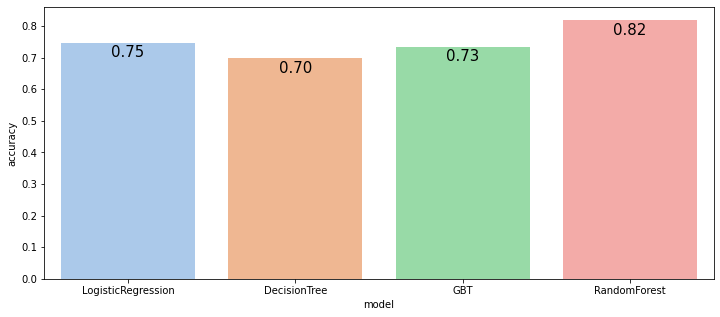

In [46]:
#create dataframe with spark
df = spark.createDataFrame([
    ('LogisticRegression', LogisticRegression_accuracy),
    ('DecisionTree', DecisionTree_accuracy),   
    ('GBT',GBT_accuracy),
    ('RandomForest',RandomForest_accuracy)
],schema='model string,accuracy double')
df.show() 

df=df.toPandas()[:10]    
sns.set_palette("pastel")
fig,ax = plt.subplots(1,1,figsize=(12,5))
chart=sns.barplot(data=df, x='model', y='accuracy')

for p in chart.patches:
             chart.annotate("%.2f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0,-10),
                 textcoords='offset points')       

plt.show()

# 8.2  f1_score 

+------------------+------------------+
|             model|          f1_score|
+------------------+------------------+
|LogisticRegression|0.7591800262016009|
|      DecisionTree|0.7175254622365902|
|               GBT|0.7496532181357007|
|      RandomForest|0.8057939190816023|
+------------------+------------------+



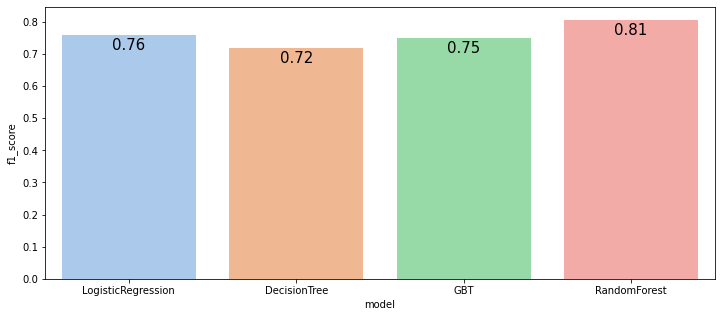

In [47]:
#create dataframe with spark
df = spark.createDataFrame([
    ('LogisticRegression', LogisticRegression_f1_score),
    ('DecisionTree', DecisionTree_f1_score),   
    ('GBT',GBT_f1_score),
    ('RandomForest',RandomForest_f1_score)
],schema='model string,f1_score double')
df.show() 
df=df.toPandas()[:10]    
sns.set_palette("pastel")
fig,ax = plt.subplots(1,1,figsize=(12,5))
chart=sns.barplot(data=df, x='model', y='f1_score')

for p in chart.patches:
             chart.annotate("%.2f" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=15, color='black', xytext=(0,-10),
                 textcoords='offset points')       

plt.show()